In [114]:
from __future__ import annotations
from typing import Union
import random
import math

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Optional rustworkx support
try:
    import rustworkx as rx
    RxGraph = rx.PyGraph
except ImportError:
    rx = None
    RxGraph = tuple()

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import Aer
from qiskit import transpile

# CPLEX import
from docplex.mp.model import Model
from quantum_greedy_util import mixer_from_graph,expectation_value_cost_shifted_with_bitstring,greedy_optimize,greedy_optimize_seq
#from classical_heuristics_util import is_vertex_cover, local_search_vertex_cover, ga_vertex_cover
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
import os
import pickle

In [115]:
local = True

# Configuration: change these constants in this file to control runs
# LIMIT: number of graphs to process (None -> all)
# REPS: number of repetitions per parameter set
LIMIT = 20

# If True, treat `LIMIT` as a per-size limit when the script iterates over
# multiple graph sizes (useful when you want N graphs per size). If False,
# LIMIT caps the total number of graphs across all sizes.
LIMIT_PER_SIZE = False

if local:
    # depths 1..4
    settings = [
        {'backend_mode': 'statevector',
         'problem_type': 'minvertexcover',
         'qaoa_variant': 'multiangle_cpm_no_cost_custom',
         'param_initialization': 'uniform',
         'optimizer': 'BFGS',
         'depth': d,
         'warm_start': False}
        for d in range(1, 5)
    ]
    print(' You are running without reading from qaoa_settings.txt - you should never see this message on solstorm!')
#/p/fm/FinleyQuinton/QAOA/QAOA_copy/QAOA_copy/run_my_qaoa/results/graphs/paper_graphs/3_regular/rdr3_20_paper_graphs_n8.pkl
# -------------------- LOAD GRAPHS -------------------- #
#erdos_20_paper_graphs_05P_n20.pkl
#rdr3_20_paper_graphs_n20.pkl
graph_dir = os.path.join(os.path.dirname('erdos_20_paper_graphs_05P_n8.pkl'), "graphs", "erdos")
from glob import glob

# include sizes 8,10,...,14
sizes = [8, 10, 12, 14,16,18,20]
graph_files = []
per_size_counts = {}
for s in sizes:
    pattern = os.path.join(graph_dir, f"*n{s}.pkl")
    found = sorted(glob(pattern))
    if not found:
        # also accept files that contain the size number elsewhere
        found = sorted(glob(os.path.join(graph_dir, f"*{s}*.pkl")))
    # Optionally limit per-size if requested
    if LIMIT is not None and LIMIT_PER_SIZE and found:
        found = found[:LIMIT]
    # record how many pickle files were found for this size (after optional per-size LIMIT)
    per_size_counts[s] = len(found)
    graph_files.extend(found)

if not graph_files:
    raise RuntimeError(f"No graph files found in {graph_dir} for sizes {sizes}")

# Print per-size summary so user can verify how many pickles were found per size
print("[INFO] graph pickle counts per requested size:")
for s in sizes:
    print(f"  n{s}: {per_size_counts.get(s, 0)}")

graph_data = []
for gf in graph_files:
    with open(gf, "rb") as f:
        try:
            data = pickle.load(f)
            if isinstance(data, list):
                graph_data.extend(data)
        except Exception as e:
            print(f"Failed to load {gf}: {e}")

graphs = [g["graph"] if isinstance(g, dict) and "graph" in g else g for g in graph_data]

 You are running without reading from qaoa_settings.txt - you should never see this message on solstorm!
[INFO] graph pickle counts per requested size:
  n8: 1
  n10: 1
  n12: 1
  n14: 1
  n16: 0
  n18: 0
  n20: 1


In [116]:
def rx_to_nx(rx_graph):

    G = nx.Graph()

     # Nodes: indices + data
    for i in rx_graph.node_indices():
        data = rx_graph[i]          # node payload
        G.add_node(i, data=data)

    # Edges: indices + weight/data
    for u, v, w in rx_graph.weighted_edge_list():
        if isinstance(w, dict):
            G.add_edge(u, v, **w)
        else:
            G.add_edge(u, v, weight=w)

    return G

In [117]:
k=-2
G=rx_to_nx(graphs[k]) if rx and isinstance(graphs[k], RxGraph) else graphs[k]

In [118]:
case="weighted"
graph_type="regular"
degree=3
shots=None
seed=None
rng = np.random.default_rng(seed)
graph_seed = rng.integers(1e9)
n=14
n_stat=1
results = {"LP": [], "Dual-Primal": [], "Greedy random edge": [], "Greedy vertex degree": [], "Quantum greedy bias": [], "Quantum greedy seq bias": []}

In [119]:
if graph_type == "erdos":
    p = degree
    G = nx.erdos_renyi_graph(n, p)
elif graph_type == "regular":
    G = nx.random_regular_graph(degree, n)

In [120]:
import networkx as nx

def plot_graph(G):
    """Plot a NetworkX graph with labels."""
    plt.figure(figsize=(4,4))
    pos = nx.spring_layout(G, seed=42)  # nice-looking layout

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=800,
        node_color="lightblue",
        font_size=12,
        font_weight="bold",
        edge_color="gray"
    )

    plt.title("Graph G")
    plt.axis("off")
    plt.show()

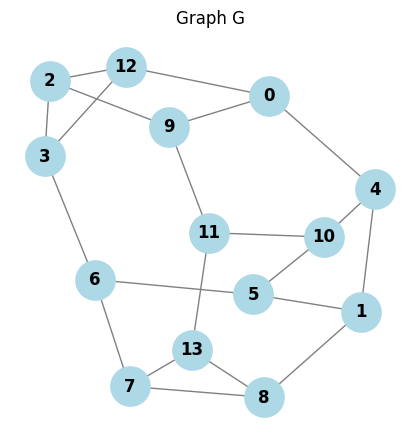

In [121]:
plot_graph(G)

In [122]:
'''"QGMVC_experiments copy.ipynb"
def node_order_by_cost_degree1(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        key=lambda i: (G.degree(i), -C[i]),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph1(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree1(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G


def node_order_by_cost_degree2(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        key=lambda i: (G.degree(i), C[i]),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph2(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree2(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G


def node_order_by_cost_degree3(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        #key=lambda i: (G.degree(i), -C[i]),
        key=lambda i: (G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph3(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree3(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G


def node_order_by_cost_degree4(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        key=lambda i: (i)
        #key=lambda i: (G.degree(i), -C[i]),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph4(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree4(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G

def node_order_by_cost_degree5(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        key=lambda i: (C[i],G.degree(i)),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph5(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree5(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G

def node_order_by_cost_degree6(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        key=lambda i: (-C[i],G.degree(i)),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph6(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree6(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G
    '''


'"QGMVC_experiments copy.ipynb"\ndef node_order_by_cost_degree1(G, C):\n    """\n    Order nodes by:\n      1) descending cost\n      2) descending degree\n    """\n    return sorted(\n        G.nodes(),\n        #key=lambda i: (i)\n        key=lambda i: (G.degree(i), -C[i]),\n        #key=lambda i: (-G.degree(i)/C[i])\n    )\n\n\n\n# ---------------- Graph & mixer ----------------\n\ndef mixer_from_graph1(G,c):\n    G = nx.convert_node_labels_to_integers(G)\n    n = G.number_of_nodes()\n    qc = QuantumCircuit(n)\n    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}\n\n    for i in range(n):\n        qc.x(i)\n    # 🔥 ORDER NODES HERE\n    ordered_nodes = node_order_by_cost_degree1(G,c)\n    for tgt in ordered_nodes:\n        angle = 2 * betas[tgt]\n        ctrls = list(G.neighbors(tgt))\n        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])\n\n\n    return qc, betas, G\n\n\ndef node_order_by_cost_degree2(G, C):\n    """\n    Order nodes by:\n      1) descending cost\n

In [123]:
def mean_field_cost_degree_order_init(G, C_cost, order, alpha=1, beta=1, gamma=1,delta=0.2, n_iter=30):
    n = len(G)
    rank = {j: k / n for k, j in enumerate(order)}
    p = {j: 0.5 for j in G.nodes()}
    maxcost= max(C_cost)
    for _ in range(n_iter):
        p_new = {}
        for j in G.nodes():
            dj = max(1, G.degree(j))
            neigh_pressure = sum(p[k] for k in G.neighbors(j)) / dj
            field = (
                alpha * C_cost[j]
                - beta * neigh_pressure
                - gamma * rank[j]
            )
            p_new[j] = 1.0 / (1.0 + np.exp(-delta*field))
        p = p_new

    return {j: np.arcsin(np.sqrt(p[j])) for j in p}


In [124]:
import networkx as nx

def is_vertex_cover(F: nx.Graph, bitstring: str):
    """
    Check if a bitstring represents a feasible vertex cover.

    Parameters
    ----------
    F : nx.Graph
        Input graph
    bitstring : str
        Binary string, one bit per node (ordered as F.nodes())

    Returns
    -------
    feasible : bool
        True if bitstring is a vertex cover
    uncovered_edges : list
        List of edges not covered (empty if feasible)
    """
    nodes = list(F.nodes())

    if len(bitstring) != len(nodes):
        raise ValueError("Bitstring length does not match number of nodes")

    cover = {
        nodes[i]
        for i, b in enumerate(bitstring)
        if b == "1"
    }

    uncovered_edges = [
        (u, v)
        for u, v in F.edges()
        if u not in cover and v not in cover
    ]

    return len(uncovered_edges) == 0, uncovered_edges
import networkx as nx

def vertex_cover_cost(
    G: nx.Graph,
    bitstring: str,
    c: dict,
    check_feasible: bool = True
):
    """
    Compute the cost of a vertex cover encoded by a bitstring.

    Parameters
    ----------
    G : nx.Graph
        Input graph
    bitstring : str
        Binary string, one bit per node (ordered as G.nodes())
    c : dict
        Cost dictionary {node: cost}
    check_feasible : bool
        If True, raise an error if bitstring is not a vertex cover

    Returns
    -------
    cost : float
        Total cost of the vertex cover
    """
    nodes = list(G.nodes())

    if len(bitstring) != len(nodes):
        raise ValueError("Bitstring length does not match number of nodes")

    cover = {
        nodes[i]
        for i, b in enumerate(bitstring)
        if b == "1"
    }

    if check_feasible:
        for u, v in G.edges():
            if u not in cover and v not in cover:
                raise ValueError(
                    f"Bitstring is not a vertex cover: edge ({u}, {v}) uncovered"
                )

    cost = sum(c[node] for node in cover)

    return cost


In [ ]:
from classical_heuristics_util import SimulatedAnnealingWeighted
#G = nx.erdos_renyi_graph(n=n, p=degree, seed=int(graph_seed))


if case == "unweighted":
    c = {i: 1.0 for i in G.nodes()}
else:
    c = {i: random.uniform(0.40, 0.70) for i in G.nodes()}

#C_opt = mvc_exact_cplex(G, c)

C_opt = mvc_exact_cplex(G, c)
opt_cost = sum(c[i] for i in C_opt)

print(C_opt)
print("Optimal cost:", opt_cost)

C_opt=SimulatedAnnealingWeighted(G,c,T=100,alpha=0.95,max_iter=1000).run()
opt_cost = sum(c[i] for i in C_opt) 
print(C_opt)
print("Optimal cost:", opt_cost)



C_lp = mvc_lp_relaxation(G, c)
results["LP"].append(sum(c[i] for i in C_lp) / opt_cost)

C_pd = mvc_primal_dual_weighted(G,  c)
results["Dual-Primal"].append(sum(c[i] for i in C_pd) / opt_cost)

C_gd = greedy_degree_vertex_cover(G,c)
results["Greedy vertex degree"].append(sum(c[i] for i in C_gd) / opt_cost)
print(sum(c[i] for i in C_gd) )
                                   
for s in range(n_stat):
    run_seed = rng.integers(1e9)
    random.seed(int(run_seed))
    np.random.seed(int(run_seed))

    C_ge = greedy_edge_vertex_cover(G,c)
    results["Greedy random edge"].append(sum(c[i] for i in C_ge) / opt_cost)

qc, betas, Gn = mixer_from_graph(G,c)

C_cost = c

beta_bias1={i: 0.8*np.pi/2 for i in C_cost} #bias
#beta_bias2={i: ((i+1)/len(C_cost)*np.pi/2) for i in C_cost} #depth dependent 
beta_bias2={i: np.pi/4+((i+1)/len(C_cost)*np.pi/2) for i in C_cost} #depth dependent 
beta_bias3={i: np.random.uniform(np.pi/4,np.pi/2) for i in C_cost} # random 
beta_bias4={i: np.pi/4 for i in C_cost} # equal 
# warm started




sol_weighted= greedy_optimize_seq(qc, betas, C_cost, beta_bias1, shots=shots)
E_weighted1,sol1= expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted1)
print(sol1[::-1],vertex_cover_cost(G,sol1[::-1],c))
Feas,uncover=is_vertex_cover(G, sol1[::-1])
print(Feas)
sol_weighted= greedy_optimize_seq(qc, betas, C_cost, beta_bias2, shots=shots)
E_weighted2,sol2 = expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted2)
print(sol2[::-1],vertex_cover_cost(G,sol2[::-1],c))
Feas,uncover=is_vertex_cover(G, sol2[::-1])
print(Feas)
sol_weighted= greedy_optimize_seq(qc, betas, C_cost, beta_bias3, shots=shots)
E_weighted3,sol3 = expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted3)
print(sol3[::-1],vertex_cover_cost(G,sol3[::-1],c))
Feas,uncover=is_vertex_cover(G, sol3[::-1])
print(Feas)
sol_weighted= greedy_optimize(qc, betas, C_cost, beta_bias1, shots=shots)
E_weighted4 ,sol4= expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted4)
print(sol4[::-1],vertex_cover_cost(G,sol4[::-1],c))
Feas,uncover=is_vertex_cover(G, sol4[::-1])
print(Feas)
sol_weighted = greedy_optimize(qc, betas, C_cost, beta_bias2, shots=shots)
E_weighted5,sol5 = expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted5)
print(sol5[::-1],vertex_cover_cost(G,sol5[::-1],c))
Feas,uncover=is_vertex_cover(G, sol5[::-1])
print(Feas)
results["Quantum greedy bias"].append(E_weighted3 / opt_cost)
sol_weighted= greedy_optimize(qc, betas, C_cost, beta_bias3, shots=shots)
E_weighted6,sol6 = expectation_value_cost_shifted_with_bitstring(qc, betas, C_cost, sol_weighted, shots=shots)
print(E_weighted6)
Feas,uncover=is_vertex_cover(G, sol6[::-1])
print(sol6[::-1],vertex_cover_cost(G,sol6[::-1],c))
print(Feas)

results["Quantum greedy seq bias"].append(E_weighted6 / opt_cost)




{0, 2, 3, 4, 5, 7, 8, 11}
Optimal cost: 4.220931534246878
{0, 2, 3, 4, 5, 7, 8, 11}
Optimal cost: 4.220931534246878
4.619493701651056
4.220931534246878
10111101100100 4.220931534246878
True
4.220931534246878
10111101100100 4.220931534246878
True
4.220931534246878
10111101100100 4.220931534246878
True


In [ ]:
15*100/60

25.0

In [ ]:
# Convert to NumPy array
data1 = np.array(en1)
data2 = np.array(en2)
data3 = np.array(en3)
data4 = np.array(en4)
data5 = np.array(en5)
data6 = np.array(en6)
# Rearrange each row: [max, min]
rearranged_data1 = np.column_stack((
    np.max(data1, axis=1),
    np.min(data1, axis=1)
))
rearranged_data2 = np.column_stack((
    np.max(data2, axis=1),
    np.min(data2, axis=1)
))
rearranged_data3 = np.column_stack((
    np.max(data3, axis=1),
    np.min(data3, axis=1)
))
rearranged_data4 = np.column_stack((
    np.max(data4, axis=1),
    np.min(data4, axis=1)
))
rearranged_data5 = np.column_stack((
    np.max(data5, axis=1),
    np.min(data5, axis=1)
))
rearranged_data6 = np.column_stack((
    np.max(data6, axis=1),
    np.min(data6, axis=1)
))
# X axis (index)
x = np.arange(len(data1))


# Plot
plt.figure()
#plt.plot(x, rearranged_data1[:, 0]/opt_cost, label="big 1")
plt.plot(x, rearranged_data1[:, 1]/opt_cost, label="small 1")
#plt.plot(x, rearranged_data2[:, 0]/opt_cost, label="big 2")
plt.plot(x, rearranged_data2[:, 1]/opt_cost, label="small 2")
#plt.plot(x, rearranged_data3[:, 0]/opt_cost, label="big 3")
plt.plot(x, rearranged_data3[:, 1]/opt_cost, label="small 3")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data4[:, 1]/opt_cost, label="small 4")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data5[:, 1]/opt_cost, label="small 5")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data6[:, 1]/opt_cost, label="small 6")
plt.axhline(y=results["Greedy vertex degree"][0], linestyle='--', linewidth=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First and Second Column")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'en1' is not defined

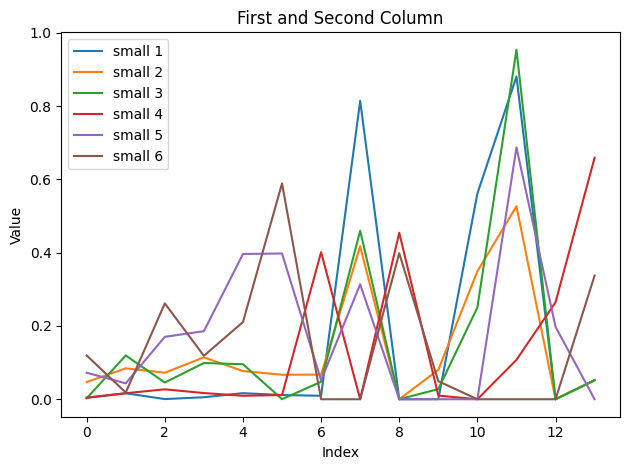

In [ ]:
# Plot
plt.figure()
#plt.plot(x, rearranged_data1[:, 0]/opt_cost, label="big 1")
plt.plot(x, -rearranged_data1[:, 1]+rearranged_data1[:, 0], label="small 1")
#plt.plot(x, rearranged_data2[:, 0]/opt_cost, label="big 2")
plt.plot(x, -rearranged_data2[:, 1]+rearranged_data2[:, 0], label="small 2")
#plt.plot(x, rearranged_data3[:, 0]/opt_cost, label="big 3")
plt.plot(x, -rearranged_data3[:, 1]+rearranged_data3[:, 0], label="small 3")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, -rearranged_data4[:, 1]+rearranged_data4[:, 0], label="small 4")
plt.plot(x, -rearranged_data5[:, 1]+rearranged_data5[:, 0], label="small 5")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, -rearranged_data6[:, 1]+rearranged_data6[:, 0], label="small 6")

#plt.axhline(y=results["Greedy vertex degree"][0], linestyle='--', linewidth=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First and Second Column")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
results

{'LP': [1.6739977579524865],
 'Dual-Primal': [1.2405251777891808],
 'Greedy random edge': [1.0],
 'Greedy vertex degree': [1.0118899007402822],
 'Quantum greedy bias': [np.float64(0.9836417454870796)],
 'Quantum greedy seq bias': [np.float64(0.9836417454870793)]}